# NEV 沙盘 · Phase 0 · 合成数据生成与验收

**六段工作流 (audit_log §H)**：① 生成 → ② 数据画像(落库前) → ③ 建表 → ④ SQL 展示(交叉验证) → ⑤ 关系检查 → ⑥ 验收。
每段独立 cell、独立输出。大段 DGP 代码在 `generate_data.py` 模块，本 notebook 只做画像/建表/展示/检查/验收。

> 诚实声明：SQL 原子数据由 DGP 合成；行为系数 β/γ 为「设定并经回归恢复验证」，非真实市场实证发现；九公司仅作锚点参照。

## ① Synthetic Data 生成
生成六张 DataFrame + `ground_truth`（内存，未入库）。

In [1]:
import numpy as np, pandas as pd, sqlite3, json
import statsmodels.api as sm
import generate_data as G
import config as CFG

tables, ground_truth = G.build(seed=CFG.RNG_SEED)
model_dim          = tables["model_dim"]
sales_transactions = tables["sales_transactions"]
macro_shocks_log   = tables["macro_shocks_log"]
regional_infra     = tables["regional_infra"]
supply_chain_costs = tables["supply_chain_costs"]
financial_snapshots= tables["financial_snapshots"]
print("生成完成。ground_truth β:", ground_truth["beta_demand"])
print("γ_effective:", ground_truth["gamma_effective"])

生成完成。ground_truth β: {'Q1': -1.3, 'Q2': -1.1, 'Q3': -1.8, 'Q4': -2.4}
γ_effective: {'Shanghai': 0.5047, 'Shenzhen': 0.3568, 'Hefei': 0.4125, 'Changzhou': 0.3717, 'Xian': 0.6249, 'Liuzhou': 0.333}


## ② 数据画像 / 总结展示（落库前 · DataFrame 侧）
对 §H2 重要列做分布摘要（mean/min/max/std），**按 quadrant 分组**，确认：生成对否、四象限可分否、落可行域否。
生成若错，到此为止，不进 SQL。

In [2]:
def profile(df, cols, by="quadrant"):
    if by not in df.columns:   # 给缺象限的表补上
        if "region" in df.columns:
            df = df.assign(quadrant=df["region"].map(CFG.REGION_QUADRANT))
    g = df.groupby(by)[cols].agg(["mean","min","max","std"]).round(2)
    return g

print("── model_dim：list_price / batt_dev（看四象限是否拉开）──")
display(profile(model_dim, ["list_price","batt_dev","adas_dev","rd_score_display"]))

── model_dim：list_price / batt_dev（看四象限是否拉开）──


list_price                               batt_dev                    \
               mean       min       max       std     mean   min   max   std   
quadrant                                                                       
Q1        179427.50  161051.0  210019.0  18181.64     3.54  1.11  6.56  2.27   
Q2        332203.67  251721.0  382811.0  50420.41     4.85  3.39  6.97  1.42   
Q3        139800.67  134827.0  144420.0   4806.31     5.92  1.31  9.11  4.09   
Q4         54875.67   48639.0   63099.0   7431.89     2.70  0.88  4.23  1.69   

         adas_dev                   rd_score_display                    
             mean   min   max   std             mean   min   max   std  
quadrant                                                                
Q1           7.25  3.61  9.72  2.22             5.15  3.66  7.63  1.38  
Q2           5.47  4.72  6.33  0.63             4.89  4.20  5.84  0.67  
Q3           3.77  2.23  6.64  2.49             5.05  2.70  6.52  2.06  
Q4           1.28  0.42  2.23  0.91             1.99  0.81  2.71  1.03

In [3]:
print("── sales_transactions：unit_price(P) / quantity(Q) ──")
display(profile(sales_transactions, ["unit_price","quantity"]))

── sales_transactions：unit_price(P) / quantity(Q) ──


unit_price                               quantity                
               mean       min       max       std     mean min  max    std
quadrant                                                                  
Q1        180867.25  103086.0  330852.0  31581.69    25.24  13   47   5.06
Q2        335882.95  164625.0  569911.0  67191.66    20.51  11   34   3.57
Q3        141583.87   86318.0  220129.0  21608.08    69.56  29  160  20.34
Q4         55867.95   28408.0  107571.0  10925.87   129.84  34  457  51.05

In [4]:
print("── supply_chain_costs：bom_cost / battery_bom_share ──")
display(profile(supply_chain_costs, ["bom_cost_per_unit","battery_bom_share"]))

── supply_chain_costs：bom_cost / battery_bom_share ──


bom_cost_per_unit                               battery_bom_share  \
                      mean       min       max       std              mean   
quadrant                                                                     
Q1               128801.78  101029.0  151011.0   9394.45              0.45   
Q2               197309.82  165767.0  227773.0  11313.91              0.30   
Q3                96729.29   80455.0  113245.0   5587.91              0.40   
Q4                40885.52   31875.0   50452.0   3527.77              0.45   

                            
           min   max   std  
quadrant                    
Q1        0.40  0.50  0.02  
Q2        0.25  0.35  0.02  
Q3        0.35  0.45  0.02  
Q4        0.40  0.50  0.02

In [5]:
print("── financial_snapshots：营收 / 净利 / 研发率 / 销售费用 ──")
display(profile(financial_snapshots,
    ["automotive_sales_revenue","net_income","rd_ratio","selling_expense"]))

── financial_snapshots：营收 / 净利 / 研发率 / 销售费用 ──


automotive_sales_revenue                                         \
                             mean          min          max          std   
quadrant                                                                   
Q1                   4.165185e+08  379072283.0  448540773.0  18894255.46   
Q2                   6.284134e+08  595310879.0  664170792.0  19362349.79   
Q3                   8.986236e+08  853250126.0  950462905.0  28899443.87   
Q4                   6.612640e+08  579986277.0  707927181.0  32285659.44   

           net_income                                      rd_ratio        \
                 mean         min         max          std     mean   min   
quadrant                                                                    
Q1       -57009734.29 -73322693.0 -45079929.0   8251786.41     0.14  0.13   
Q2        -9604276.33 -41106249.0  19072685.0  14362223.55     0.09  0.08   
Q3        14916592.92  -3527080.0  37320012.0  13543362.04     0.06  0.06   
Q4        -2047256.25 -21524880.0  17779905.0  12074921.69     0.03  0.02   

                     selling_expense                                      
           max   std            mean         min         max         std  
quadrant                                                                  
Q1        0.16  0.01     49905682.92  35008117.0  64668919.0  7466491.46  
Q2        0.10  0.01     65521299.25  43940238.0  84864869.0  9886326.50  
Q3        0.07  0.00     65339820.58  48724008.0  80401580.0  9692348.19  
Q4        0.03  0.00     32338063.17  24549213.0  42827547.0  4808805.35

In [6]:
print("── regional_infra：市场天花板 / 电池集群 ──")
display(profile(regional_infra, ["local_market_size","local_battery_cluster_index"]))
print("\n── macro_shocks_log：全国日频(无象限，看全局分布)──")
display(macro_shocks_log[["lithium_price_index","semiconductor_price_index",
                          "macro_interest_rate"]].describe().round(3))

── regional_infra：市场天花板 / 电池集群 ──


local_market_size                   local_battery_cluster_index  \
                      mean   min   max   std                        mean   
quadrant                                                                   
Q1                    0.63  0.56  0.70  0.07                        0.70   
Q2                    0.63  0.35  0.91  0.29                        0.65   
Q3                    0.24  0.24  0.24  0.00                        0.50   
Q4                    0.36  0.36  0.36  0.00                        0.30   

                            
           min   max   std  
quadrant                    
Q1        0.55  0.85  0.15  
Q2        0.60  0.70  0.05  
Q3        0.50  0.50  0.00  
Q4        0.30  0.30  0.00


── macro_shocks_log：全国日频(无象限，看全局分布)──


,lithium_price_index,semiconductor_price_index,macro_interest_rate
count,1095.000,1095.000,1095.000
mean,95.187,98.394,0.027
std,13.325,14.195,0.006
min,58.380,54.730,0.015
25%,85.900,89.520,0.022
50%,95.430,97.600,0.026
75%,105.685,107.425,0.031
max,130.830,134.890,0.038


## ③ SQL 生成
建表 + 写入 `nev.db`。复合主键在此声明。

In [7]:
conn = sqlite3.connect("nev.db")
cur = conn.cursor()
for t in ["model_dim","sales_transactions","macro_shocks_log",
          "regional_infra","supply_chain_costs","financial_snapshots"]:
    cur.execute(f"DROP TABLE IF EXISTS {t}")

cur.executescript("""
CREATE TABLE model_dim (
  model_id TEXT PRIMARY KEY, brand TEXT, model_name TEXT, variant TEXT,
  region_archetype TEXT, powertrain_focus TEXT, price_tier TEXT, quadrant TEXT,
  list_price REAL, battery_capacity_kwh REAL, range_km REAL, charging_speed_kw REAL,
  customer_rating REAL, batt_dev REAL, adas_dev REAL, chip_dev REAL, rd_score_display REAL);
CREATE TABLE sales_transactions (
  transaction_id TEXT PRIMARY KEY, txn_date TEXT, region TEXT,
  model_id TEXT, unit_price REAL, quantity INTEGER,
  FOREIGN KEY(model_id) REFERENCES model_dim(model_id));
CREATE TABLE macro_shocks_log (
  shock_date TEXT PRIMARY KEY, lithium_price_index REAL, nickel_cobalt_index REAL,
  rare_earth_index REAL, steel_aluminum_index REAL, semiconductor_price_index REAL,
  carbon_credit_price REAL, macro_interest_rate REAL, national_subsidy_rate REAL,
  upstream_policy_index REAL, inflation_index REAL);
CREATE TABLE regional_infra (
  region TEXT, period TEXT, station_count INTEGER, port_count INTEGER,
  fast_station_share REAL, is_swap_available INTEGER, swap_partnership INTEGER,
  local_battery_cluster_index REAL, local_subsidy_bonus REAL, local_market_size REAL,
  local_gdp_index REAL, gov_investment REAL, local_fiscal_capacity REAL,
  tax_incentive_index REAL, PRIMARY KEY(region, period));
CREATE TABLE supply_chain_costs (
  batch_id TEXT PRIMARY KEY, cost_date TEXT, region TEXT, quadrant TEXT,
  component_type TEXT, bom_cost_per_unit REAL, battery_bom_share REAL,
  automotive_cogs_per_unit REAL);
CREATE TABLE financial_snapshots (
  region TEXT, quadrant TEXT, period TEXT, total_revenue REAL,
  automotive_sales_revenue REAL, service_revenue REAL, regulatory_credit_revenue REAL,
  total_cost_of_revenue REAL, automotive_cost_of_revenue REAL, depreciation_amortization REAL,
  gross_profit REAL, operating_income REAL, tax_rate REAL, net_income REAL,
  total_assets REAL, shareholders_equity REAL, interest_bearing_debt REAL,
  cash_and_equivalents REAL, total_deliveries INTEGER, rd_ratio REAL, capex REAL,
  selling_expense REAL, fcf REAL, PRIMARY KEY(region, quadrant, period));
""")
conn.commit()

for name, df in tables.items():
    df.to_sql(name, conn, if_exists="append", index=False)
cur.execute("CREATE INDEX idx_sales_region ON sales_transactions(region)")
cur.execute("CREATE INDEX idx_fin_rq ON financial_snapshots(region, quadrant)")
conn.commit()
print("nev.db 建表 + 写入完成")

nev.db 建表 + 写入完成


## ④ SQL 初步展示（落库后 · SQL 侧）
逐表 `head` + `COUNT(*)`；再用 SQL **复算 ② 的同一批变量**，与 ② 的 DataFrame 结果对照——数一致 = 落库无损。

In [8]:
for t in ["model_dim","sales_transactions","macro_shocks_log",
          "regional_infra","supply_chain_costs","financial_snapshots"]:
    n = pd.read_sql(f"SELECT COUNT(*) c FROM {t}", conn)["c"][0]
    print(f"── {t}: {n} rows ──")
    display(pd.read_sql(f"SELECT * FROM {t} LIMIT 5", conn))

── model_dim: 18 rows ──


,model_id,brand,model_name,variant,region_archetype,powertrain_focus,price_tier,quadrant,list_price,battery_capacity_kwh,range_km,charging_speed_kw,customer_rating,batt_dev,adas_dev,chip_dev,rd_score_display
0,SHA_PREM_001,Shanghai_Brand,Q1_Model_1,Base,Shanghai,BEV,Premium,Q1,183460.0,86.6,594.0,408.0,2.21,1.31,9.72,6.68,4.91
1,SHA_PREM_002,Shanghai_Brand,Q1_Model_2,LongRange,Shanghai,BEV,Premium,Q1,210019.0,90.8,581.0,75.0,4.84,1.11,5.97,6.58,3.66
2,SHA_PREM_003,Shanghai_Brand,Q1_Model_3,Performance,Shanghai,BEV,Premium,Q1,161051.0,86.5,578.0,180.0,2.21,6.56,8.78,8.58,7.63
3,SHE_PREM_001,Shenzhen_Brand,Q2_Model_1,Base,Shenzhen,Multi,Premium,Q2,382811.0,52.8,651.0,64.0,3.74,3.39,6.33,4.05,4.41
4,SHE_PREM_002,Shenzhen_Brand,Q2_Model_2,LongRange,Shenzhen,Multi,Premium,Q2,365670.0,45.7,382.0,113.0,2.87,3.81,6.04,2.42,4.20


── sales_transactions: 6570 rows ──


,transaction_id,txn_date,region,model_id,unit_price,quantity
0,TXN_20230101_SHA_000001,2023-01-01,Shanghai,SHA_PREM_001,228628.0,17
1,TXN_20230104_SHA_000002,2023-01-04,Shanghai,SHA_PREM_001,142379.0,36
2,TXN_20230107_SHA_000003,2023-01-07,Shanghai,SHA_PREM_001,208902.0,21
3,TXN_20230110_SHA_000004,2023-01-10,Shanghai,SHA_PREM_001,194816.0,24
4,TXN_20230113_SHA_000005,2023-01-13,Shanghai,SHA_PREM_001,162376.0,28


── macro_shocks_log: 1095 rows ──


...

,region,period,station_count,port_count,fast_station_share,is_swap_available,swap_partnership,local_battery_cluster_index,local_subsidy_bonus,local_market_size,local_gdp_index,gov_investment,local_fiscal_capacity,tax_incentive_index
0,Shanghai,2023-Q1,3415,32293,0.172,0,1,0.55,0.0168,0.703,0.766,0.446,0.744,0.717
1,Shanghai,2023-Q2,7225,44463,0.348,1,0,0.55,0.0163,0.703,0.635,0.567,0.355,0.270
2,Shanghai,2023-Q3,9333,2467,0.585,0,0,0.55,0.0154,0.703,0.629,0.660,0.728,0.926
3,Shanghai,2023-Q4,8773,28458,0.374,0,0,0.55,0.0303,0.703,0.749,0.933,0.651,0.868
4,Shanghai,2024-Q1,14415,73945,0.816,1,0,0.55,0.0213,0.703,0.776,0.735,0.766,0.457


── supply_chain_costs: 1314 rows ──


,batch_id,cost_date,region,quadrant,component_type,bom_cost_per_unit,battery_bom_share,automotive_cogs_per_unit
0,BATCH_20230101_SHA_000001,2023-01-01,Shanghai,Q1,battery_pack,126661.0,0.423,145660.0
1,BATCH_20230106_SHA_000002,2023-01-06,Shanghai,Q1,e_drive,129570.0,0.431,149006.0
2,BATCH_20230111_SHA_000003,2023-01-11,Shanghai,Q1,domain_controller,125474.0,0.474,144295.0
3,BATCH_20230116_SHA_000004,2023-01-16,Shanghai,Q1,chip,126034.0,0.467,144939.0
4,BATCH_20230121_SHA_000005,2023-01-21,Shanghai,Q1,raw_material,134172.0,0.457,154298.0


── financial_snapshots: 72 rows ──


,region,quadrant,period,total_revenue,automotive_sales_revenue,service_revenue,regulatory_credit_revenue,total_cost_of_revenue,automotive_cost_of_revenue,depreciation_amortization,...,net_income,total_assets,shareholders_equity,interest_bearing_debt,cash_and_equivalents,total_deliveries,rd_ratio,capex,selling_expense,fcf
0,Changzhou,Q2,2023-Q1,742739514.0,633607147.0,107077642.0,2054725.0,562209711.0,487255361.0,50992344.0,...,-17995430.0,925911713.0,261436888.0,77586073.0,200252788.0,1895,0.0856,57483538.0,84864869.0,-21592545.0
1,Changzhou,Q2,2023-Q2,702489008.0,658341887.0,42012184.0,2134937.0,560807260.0,531398732.0,38920665.0,...,-14224337.0,987120668.0,284916344.0,75992263.0,283613643.0,1928,0.0996,68744174.0,47060155.0,-41213219.0
2,Changzhou,Q2,2023-Q3,686938918.0,599751530.0,85242454.0,1944935.0,529053349.0,469383631.0,37282889.0,...,-16830965.0,880437589.0,240676163.0,43142558.0,150556805.0,1841,0.0929,79706685.0,75842109.0,-57645479.0
3,Changzhou,Q2,2023-Q4,681554476.0,624858924.0,54669196.0,2026355.0,529853088.0,491584650.0,23718424.0,...,-1806811.0,800727618.0,208593627.0,62614143.0,169426825.0,1879,0.0997,72459352.0,59343035.0,-48212137.0
4,Changzhou,Q2,2024-Q1,722931321.0,639086658.0,81772168.0,2072495.0,562742658.0,505502140.0,40912092.0,...,-10019190.0,873132688.0,258265015.0,74978500.0,191426842.0,1881,0.0944,52481396.0,60039403.0,-18791683.0


In [9]:
print("── SQL 复算：sales 按象限的 P/Q 均值（对照 ② 的 DataFrame 画像）──")
q = """
SELECT m.quadrant,
       ROUND(AVG(s.unit_price),2) AS avg_unit_price,
       ROUND(AVG(s.quantity),2)   AS avg_quantity,
       COUNT(*)                    AS n
FROM sales_transactions s JOIN model_dim m USING(model_id)
GROUP BY m.quadrant ORDER BY m.quadrant"""
sql_res = pd.read_sql(q, conn)
display(sql_res)

# 交叉验证：与 ② 的 pandas 结果比对
pd_res = (sales_transactions.assign(quadrant=lambda d: d.model_id.map(
            dict(zip(model_dim.model_id, model_dim.quadrant))))
          .groupby("quadrant").agg(avg_unit_price=("unit_price","mean"),
                                   avg_quantity=("quantity","mean")).round(2))
merged = sql_res.set_index("quadrant")[["avg_unit_price","avg_quantity"]].join(
            pd_res, lsuffix="_sql", rsuffix="_pd")
merged["match"] = np.isclose(merged.avg_unit_price_sql, merged.avg_unit_price_pd, atol=0.5)
print("落库无损交叉验证：")
display(merged)
assert merged["match"].all(), "SQL 与 DataFrame 不一致 → 落库有损！"
print("✅ ④ SQL 复算与 ② DataFrame 一致，落库无损")

── SQL 复算：sales 按象限的 P/Q 均值（对照 ② 的 DataFrame 画像）──


,quadrant,avg_unit_price,avg_quantity,n
0,Q1,180867.25,25.24,2190
1,Q2,335882.95,20.51,2190
2,Q3,141583.87,69.56,1095
3,Q4,55867.95,129.84,1095


落库无损交叉验证：


,avg_unit_price_sql,avg_quantity_sql,avg_unit_price_pd,avg_quantity_pd,match
quadrant,,,,,
Q1,180867.25,25.24,180867.25,25.24,True
Q2,335882.95,20.51,335882.95,20.51,True
Q3,141583.87,69.56,141583.87,69.56,True
Q4,55867.95,129.84,55867.95,129.84,True


✅ ④ SQL 复算与 ② DataFrame 一致，落库无损


## ⑤ 关系完整性检验
外键 · 复合键 · 维度关联，三类各一查询。

In [10]:
# 外键：sales.model_id → model_dim 无孤儿
orphans = pd.read_sql("""
  SELECT COUNT(*) c FROM sales_transactions s
  LEFT JOIN model_dim m USING(model_id) WHERE m.model_id IS NULL""", conn)["c"][0]
print(f"外键孤儿行 (应=0): {orphans}")

# 复合键：financial_snapshots (region,quadrant,period) 唯一无重
dup = pd.read_sql("""
  SELECT region,quadrant,period,COUNT(*) c FROM financial_snapshots
  GROUP BY region,quadrant,period HAVING c>1""", conn)
print(f"复合主键重复组 (应=0): {len(dup)}")

# 维度关联：sales.region 是否都在 regional_infra
missing = pd.read_sql("""
  SELECT DISTINCT s.region FROM sales_transactions s
  WHERE s.region NOT IN (SELECT DISTINCT region FROM regional_infra)""", conn)
print(f"sales 中不在 regional_infra 的 region (应=0): {len(missing)}")

assert orphans==0 and len(dup)==0 and len(missing)==0, "关系完整性失败"
print("✅ ⑤ 关系完整性通过")

外键孤儿行 (应=0): 0
复合主键重复组 (应=0): 0
sales 中不在 regional_infra 的 region (应=0): 0
✅ ⑤ 关系完整性通过


## ⑥ 结果验收（audit_log §E）
参数恢复（β with model fixed effects vs ground_truth）+ 会计恒等式 + 可分性 assert。

In [11]:
# E1 参数恢复：β（模型固定效应，该 DGP 的正确设定）
s = sales_transactions.assign(
        quadrant=lambda d: d.model_id.map(dict(zip(model_dim.model_id, model_dim.quadrant))),
        lnP=lambda d: np.log(d.unit_price), lnQ=lambda d: np.log(d.quantity))
rows=[]
for quad in ["Q1","Q2","Q3","Q4"]:
    d=s[s.quadrant==quad]
    dum=pd.get_dummies(d.model_id, drop_first=True).astype(float)
    X=sm.add_constant(pd.concat([d[["lnP"]].reset_index(drop=True),
                                 dum.reset_index(drop=True)],axis=1))
    m=sm.OLS(d.lnQ.values, X.values).fit()
    b=m.params[1]; ci=m.conf_int()[1]; true=CFG.BETA_DEMAND[quad]
    rows.append(dict(quadrant=quad, true_beta=true, est=round(b,3),
                     ci_lo=round(ci[0],3), ci_hi=round(ci[1],3),
                     cover=bool(ci[0]<=true<=ci[1]), R2=round(m.rsquared,3)))
recov=pd.DataFrame(rows); display(recov)
assert recov.cover.all(), "β 参数恢复失败：CI 未覆盖真值"
print("✅ E1 β 参数恢复：4/4 CI 覆盖真值")

,quadrant,true_beta,est,ci_lo,ci_hi,cover,R2
0,Q1,-1.3,-1.284,-1.302,-1.266,True,0.899
1,Q2,-1.1,-1.104,-1.122,-1.085,True,0.867
2,Q3,-1.8,-1.822,-1.846,-1.798,True,0.954
3,Q4,-2.4,-2.392,-2.416,-2.367,True,0.972


✅ E1 β 参数恢复：4/4 CI 覆盖真值


In [12]:
# E2 会计恒等式：收入 = 汽车+服务+碳积分；毛利 = 收入-成本-折旧
f=financial_snapshots
id1=np.allclose(f.total_revenue, f.automotive_sales_revenue+f.service_revenue+f.regulatory_credit_revenue, atol=1)
id2=np.allclose(f.gross_profit, f.total_revenue-f.total_cost_of_revenue-f.depreciation_amortization, atol=1)
neg_q=(sales_transactions.quantity<=0).sum()
print(f"恒等式 收入拆分: {id1} | 毛利: {id2} | 负销量: {neg_q}")
assert id1 and id2 and neg_q==0, "会计恒等式/正性失败"
print("✅ E2 会计恒等式成立，无负销量")

恒等式 收入拆分: True | 毛利: True | 负销量: 0
✅ E2 会计恒等式成立，无负销量


In [13]:
# E4 可分性：四象限 ASP 均值显著分离
asp=model_dim.groupby("quadrant").list_price.agg(["mean","std"])
display(asp.round(0))
gap_ok = asp["mean"].max()/asp["mean"].min() > 2   # 高低象限 ASP 差 2x 以上
assert gap_ok, "四象限未拉开"
print("✅ E4 四象限可分（ASP 高低差 >2x）")

# 落库门槛：无非中国项
assert "Tesla" not in model_dim.brand.str.cat(), "特斯拉绝对额不应入库"
print("✅ E5 落库门槛：无非中国口径行")
print("\n🎉 Phase 0 验收全绿 → 可打 tag v0.1")
conn.close()

,mean,std
quadrant,,
Q1,179428.0,18182.0
Q2,332204.0,50420.0
Q3,139801.0,4806.0
Q4,54876.0,7432.0


✅ E4 四象限可分（ASP 高低差 >2x）
✅ E5 落库门槛：无非中国口径行

🎉 Phase 0 验收全绿 → 可打 tag v0.1


## ⑦ 可视化（成绩单三图）
① 四象限可分 · ② 参数恢复 · ④ 生命周期。可复用，每次跑都出图。

In [14]:
# 中文字体（Colab 需装 Noto CJK；本地已装可跳过 apt 行）
import matplotlib, matplotlib.pyplot as plt
from matplotlib import font_manager as fm
import os, glob
cand = glob.glob("/usr/share/fonts/**/NotoSansCJK*.*", recursive=True) + \
       glob.glob("/usr/share/fonts/**/NotoSerifCJK*.*", recursive=True)
if not cand:
    os.system("apt-get install -y fonts-noto-cjk >/dev/null 2>&1")
    cand = glob.glob("/usr/share/fonts/**/NotoSansCJK*.*", recursive=True) + \
           glob.glob("/usr/share/fonts/**/NotoSerifCJK*.*", recursive=True)
if cand:
    fm.fontManager.addfont(cand[0])
    plt.rcParams["font.family"] = fm.FontProperties(fname=cand[0]).get_name()
plt.rcParams["axes.unicode_minus"] = False
QC = {"Q1":"#378ADD","Q2":"#1D9E75","Q3":"#8A5CD6","Q4":"#D8792E"}

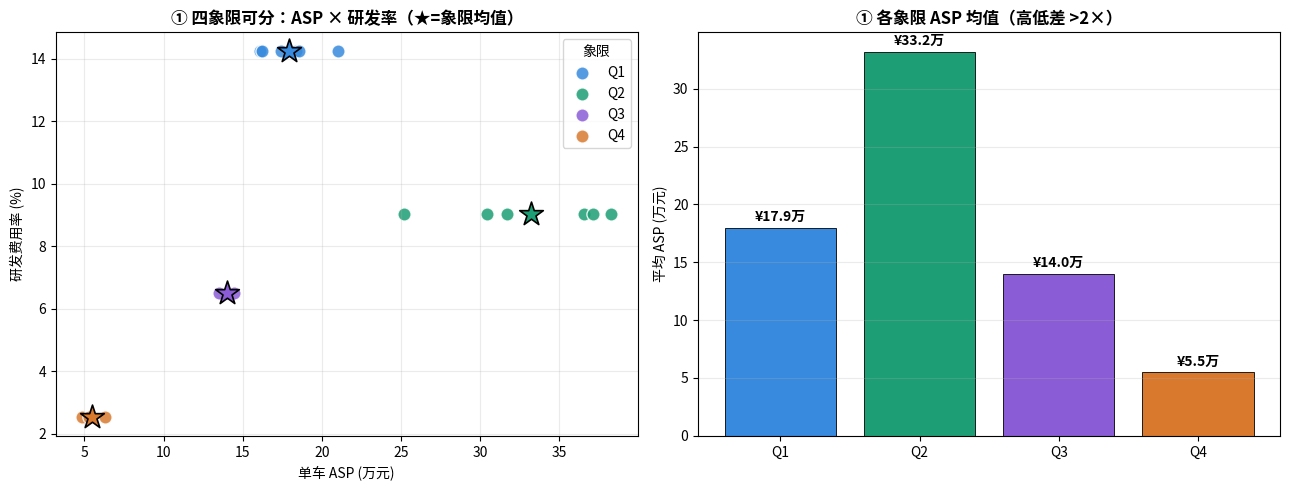

In [15]:
# ① 四象限可分
fig, ax = plt.subplots(1,2, figsize=(13,5))
md_ = model_dim.copy()
rd_map = model_dim.merge(financial_snapshots[["quadrant","rd_ratio"]], on="quadrant")\
                 .groupby("quadrant").rd_ratio.mean().to_dict()
for q in ["Q1","Q2","Q3","Q4"]:
    d = md_[md_.quadrant==q]
    ax[0].scatter(d.list_price/1e4, [rd_map[q]*100]*len(d), s=90, c=QC[q], label=q,
                  edgecolors="white", linewidth=1, alpha=0.85)
    ax[0].scatter([d.list_price.mean()/1e4],[rd_map[q]*100], s=320, marker="*",
                  c=QC[q], edgecolors="black", linewidth=1.2, zorder=5)
ax[0].set_xlabel("单车 ASP (万元)"); ax[0].set_ylabel("研发费用率 (%)")
ax[0].set_title("① 四象限可分：ASP × 研发率（★=象限均值）", fontweight="bold")
ax[0].legend(title="象限"); ax[0].grid(alpha=0.25)
qa = md_.groupby("quadrant").list_price.mean()/1e4
ax[1].bar(qa.index, qa.values, color=[QC[q] for q in qa.index], edgecolor="black", linewidth=0.6)
for i,(q,v) in enumerate(qa.items()): ax[1].text(i, v+0.6, f"¥{v:.1f}万", ha="center", fontweight="bold")
ax[1].set_ylabel("平均 ASP (万元)"); ax[1].set_title("① 各象限 ASP 均值（高低差 >2×）", fontweight="bold")
ax[1].grid(alpha=0.25, axis="y")
plt.tight_layout(); plt.show()

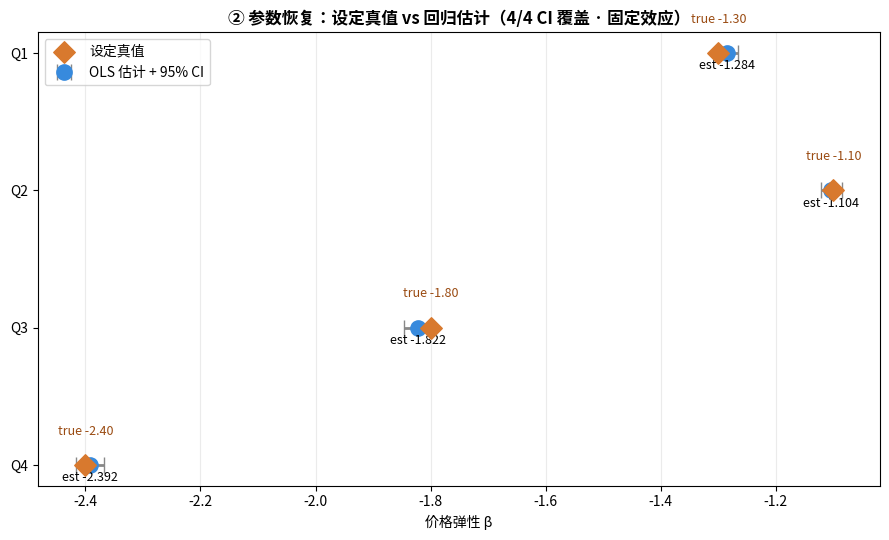

In [16]:
# ② 参数恢复
import numpy as np, pandas as pd, statsmodels.api as sm
s = sales_transactions.assign(
        quadrant=lambda d: d.model_id.map(dict(zip(model_dim.model_id, model_dim.quadrant))),
        lnP=lambda d: np.log(d.unit_price), lnQ=lambda d: np.log(d.quantity))
rows=[]
for q in ["Q1","Q2","Q3","Q4"]:
    d=s[s.quadrant==q]; dum=pd.get_dummies(d.model_id, drop_first=True).astype(float)
    X=sm.add_constant(pd.concat([d[["lnP"]].reset_index(drop=True), dum.reset_index(drop=True)],axis=1))
    m=sm.OLS(d.lnQ.values, X.values).fit(); b=m.params[1]; ci=m.conf_int()[1]
    rows.append((q, CFG.BETA_DEMAND[q], b, ci[0], ci[1]))
R=pd.DataFrame(rows, columns=["q","true","est","lo","hi"]); y=np.arange(len(R))
fig,ax=plt.subplots(figsize=(9,5.5))
ax.errorbar(R.est,y,xerr=[R.est-R.lo,R.hi-R.est],fmt="o",ms=11,capsize=6,
            color="#378ADD",ecolor="#888",elinewidth=2,label="OLS 估计 + 95% CI")
ax.scatter(R.true,y,marker="D",s=120,c="#D8792E",zorder=5,label="设定真值")
for i,r in R.iterrows():
    ax.text(r.est,i+0.12,f"est {r.est:.3f}",ha="center",fontsize=9)
    ax.text(r.true,i-0.22,f"true {r.true:.2f}",ha="center",fontsize=9,color="#9A4B12")
ax.set_yticks(y); ax.set_yticklabels(R.q); ax.invert_yaxis(); ax.set_xlabel("价格弹性 β")
ax.set_title("② 参数恢复：设定真值 vs 回归估计（4/4 CI 覆盖 · 固定效应）", fontweight="bold")
ax.legend(); ax.grid(alpha=0.25, axis="x"); plt.tight_layout(); plt.show()

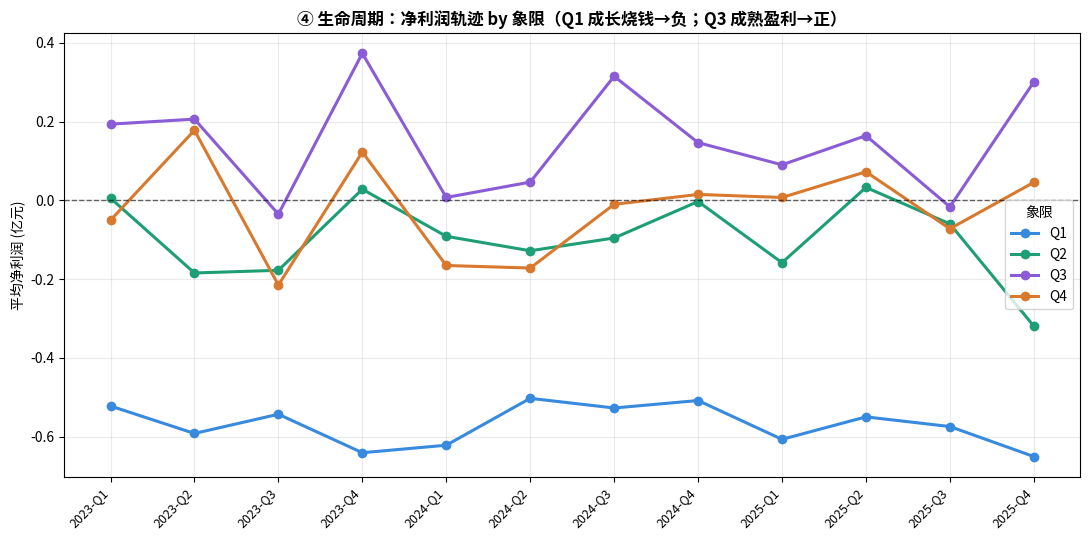

In [17]:
# ④ 生命周期
f = financial_snapshots.copy(); order = sorted(f.period.unique())
fig,ax=plt.subplots(figsize=(11,5.5))
for q in ["Q1","Q2","Q3","Q4"]:
    d=f[f.quadrant==q].groupby("period").net_income.mean().reindex(order)/1e8
    ax.plot(range(len(order)), d.values, marker="o", color=QC[q], lw=2.2, label=q)
ax.axhline(0, color="black", lw=1, ls="--", alpha=0.6)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("平均净利润 (亿元)")
ax.set_title("④ 生命周期：净利润轨迹 by 象限（Q1 成长烧钱→负；Q3 成熟盈利→正）", fontweight="bold")
ax.legend(title="象限"); ax.grid(alpha=0.25); plt.tight_layout(); plt.show()